In [26]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

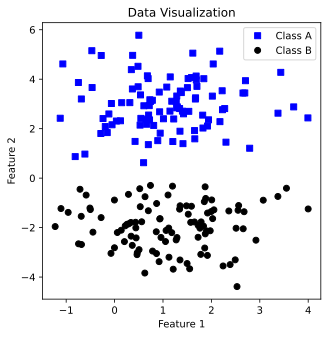

In [27]:
# Create Data

num_samples = 100
blur = 1
A = [1, 3]
B = [1,-2]

# generate data
a = [A[0] + np.random.randn(num_samples) *blur, A[1] + np.random.randn(num_samples) *blur]
b = [B[0] + np.random.randn(num_samples) *blur, B[1] + np.random.randn(num_samples) *blur]

# True labels
labels_np = np.vstack((np.zeros((num_samples, 1)), np.ones((num_samples, 1))))

# concatenate into a matrix
data_np = np.hstack((a, b)).T

# Convert to PyTorch tensors
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# Visualize the data
figure = plt.figure(figsize=(5, 5))
plt.plot(data[np.where(labels == 0)[0], 0], data[np.where(labels == 0)[0], 1], 'bs', label='Class A')
plt.plot(data[np.where(labels == 1)[0], 0], data[np.where(labels == 1)[0], 1], 'ko', label='Class B')
plt.title('Data Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [28]:
# Create a model
def create_model(lr):

    # model architecture
    ANN_classify = nn.Sequential(
        nn.Linear(2,16),
        nn.ReLU(),
        nn.Linear(16,1),
        nn.ReLU(),
        nn.Linear(1,1), 
        nn.Sigmoid()
    )

    # Loss Function
    loss_fn = nn.BCELoss()

    # Optimizer
    # The optimizer is simply the flavor of Gradient Decent used. In this case, we are using Stochastic Gradient Descent (SGD).
    optimizer = torch.optim.SGD(ANN_classify.parameters(), lr=lr)

    return ANN_classify, loss_fn, optimizer


In [ ]:
# Train the model
num_epochs = 1000

def train_model(model, loss_fn, optimizer):

    # Initialize the losses
    losses = torch.zeros(num_epochs)

    for epoch in range(num_epochs):
        # forward pass
        y_hat = model(data)
        # Compute the loss
        loss = loss_fn(y_hat, labels)
        losses[epoch] = loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward() 
        optimizer.step()

    
    # Final Foward Pass
    predictions = model(data)

    total_accuracy = 100*torch.mean(((predictions > .5)== labels).float())

    return losses, predictions, total_accuracy

Final Accuracy: 100%


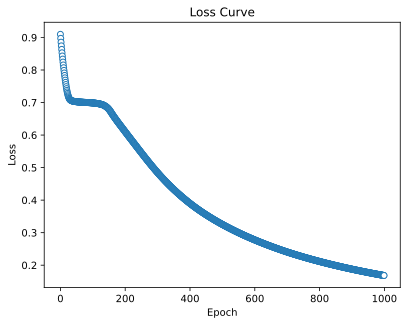

In [36]:
Ann_model, loss_fn, optimizer = create_model(lr=0.01)

losses, predictions, total_accuracy = train_model(Ann_model, loss_fn, optimizer)

print('Final Accuracy: %g%%' % total_accuracy.item())

# Visualize the loss curve
plt.plot(losses.detach(), 'o', markerfacecolor='w', linewidth=.1)
plt.xlabel('Epoch'), plt.ylabel('Loss'), plt.title('Loss Curve')
plt.show()

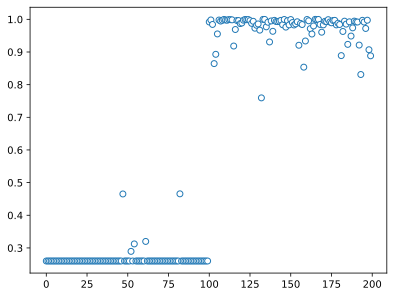

In [37]:
plt.plot(predictions.detach(), 'o', markerfacecolor='w', linewidth=.1)

In [31]:
# Set of learning rate for the parametric experiment

learning_rates = np.linspace(.001, .1, 50)

# Initialize result output
results = []
all_losses = np.zeros((len(learning_rates), num_epochs))


for i, lr in enumerate(learning_rates):

    Ann_model, loss_fn, optimizer = create_model(lr=lr)

    losses, predictions, total_accuracy = train_model(Ann_model, loss_fn, optimizer)

    results.append(total_accuracy)
    all_losses[i, :] = losses.detach()



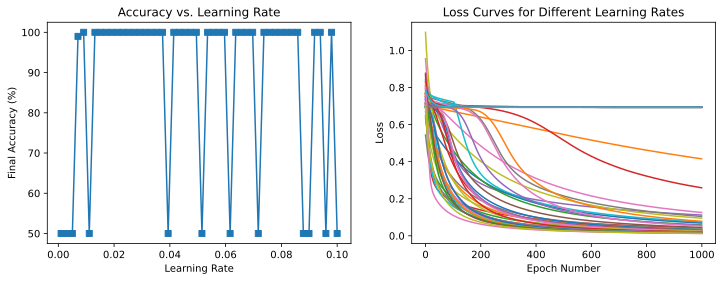

In [32]:
# Visualize the results
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(learning_rates, results, 's-')
ax[0].set_xlabel('Learning Rate')
ax[0].set_ylabel('Final Accuracy (%)')
ax[0].set_title('Accuracy vs. Learning Rate')

ax[1].plot(all_losses.T)
ax[1].set_title('Loss Curves for Different Learning Rates')
ax[1].set_xlabel('Epoch Number')
ax[1].set_ylabel('Loss')
plt.show()

In [33]:
# Proportion of learning rates that achieved an accuracy greater than 70%
sum(torch.tensor(results) > 70)/len(results)

tensor(0.7600)